# Interaktive Analyse & Metriken-Explorer

Dieses Notebook importiert die modularisierten Analyse- und Vergleichswerkzeuge aus dem `utils_notebook`-Ordner und führt sie nacheinander aus.

## Phase 0

In [11]:
import sys
import os

# Pfad anpassen, um utils_notebook importieren zu können
if os.path.abspath('..') not in sys.path:
    sys.path.append(os.path.abspath('..'))

# Nur noch die benötigten Imports aus dem L&R-Modul
from utils_notebook.LR_utils_notebook.compare_LR import (
    compare_wunden_interactive, 
    compare_categories_interactive,
    calculate_summary_LR,
    display_summary_LR,
    calculate_experts_summary_LR,
    compare_wunden_trace_interactive,
    compare_categories_trace_interactive,
    calculate_consensus_summary_LR
)
from utils_notebook.plot_compare import plot_gt_comparison

In [12]:
compare_wunden_interactive(normalised=False)

In [13]:
compare_categories_interactive(normalised=False)

## Phase 2

In [14]:
compare_wunden_interactive(normalised=True)
compare_categories_interactive(normalised=True)

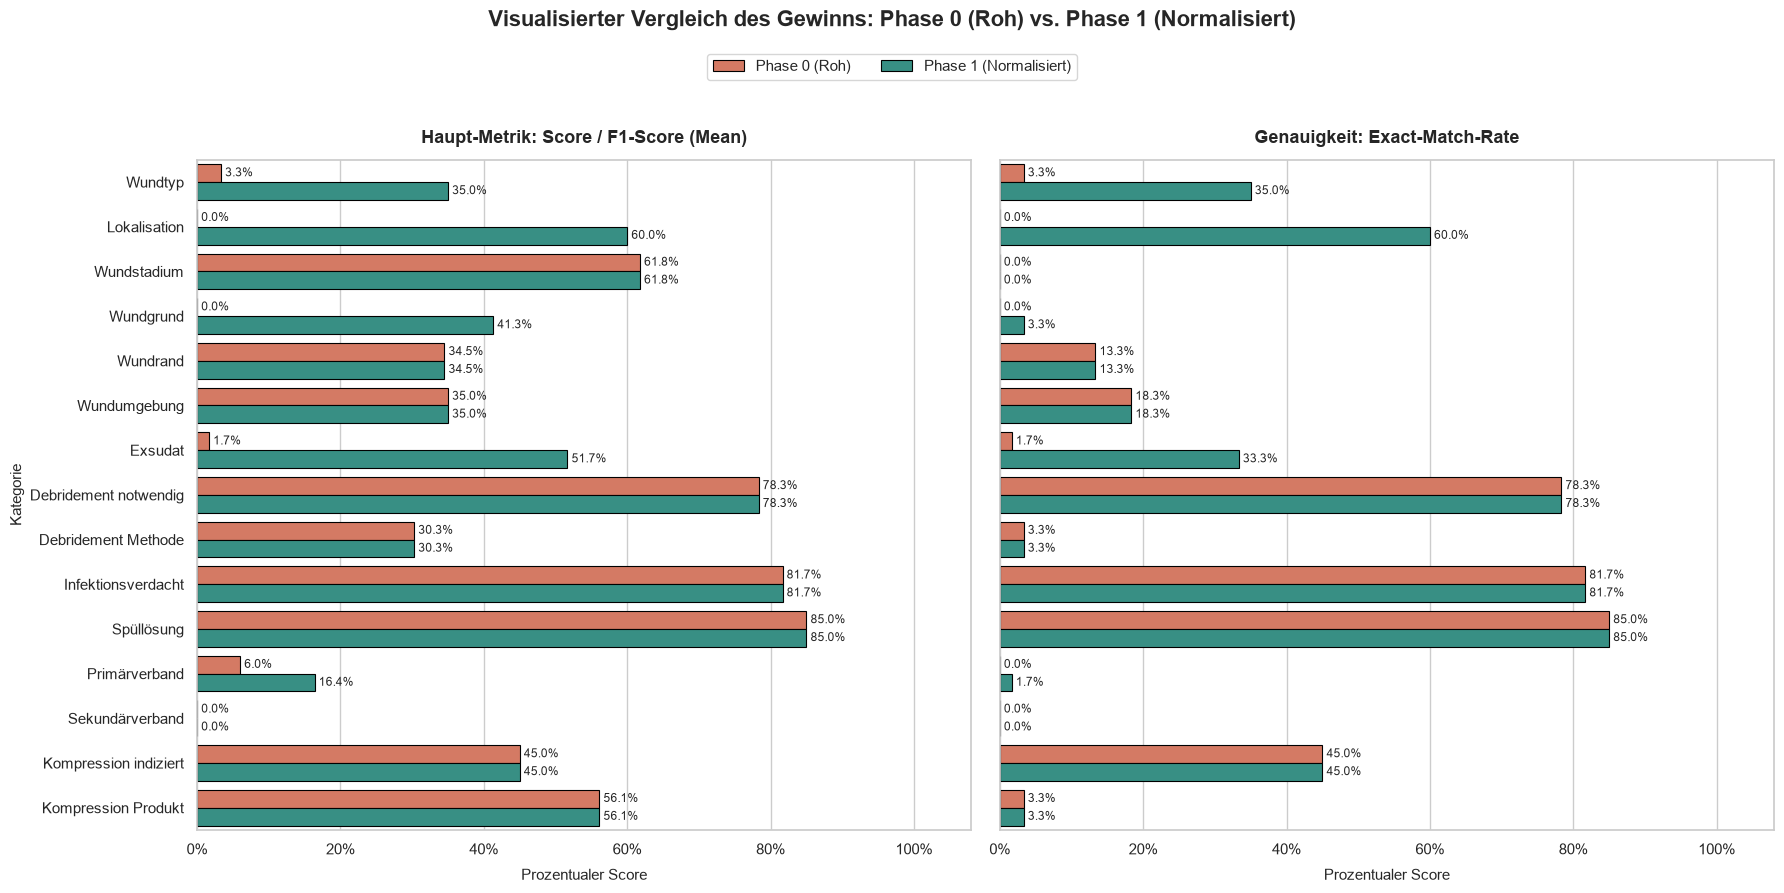

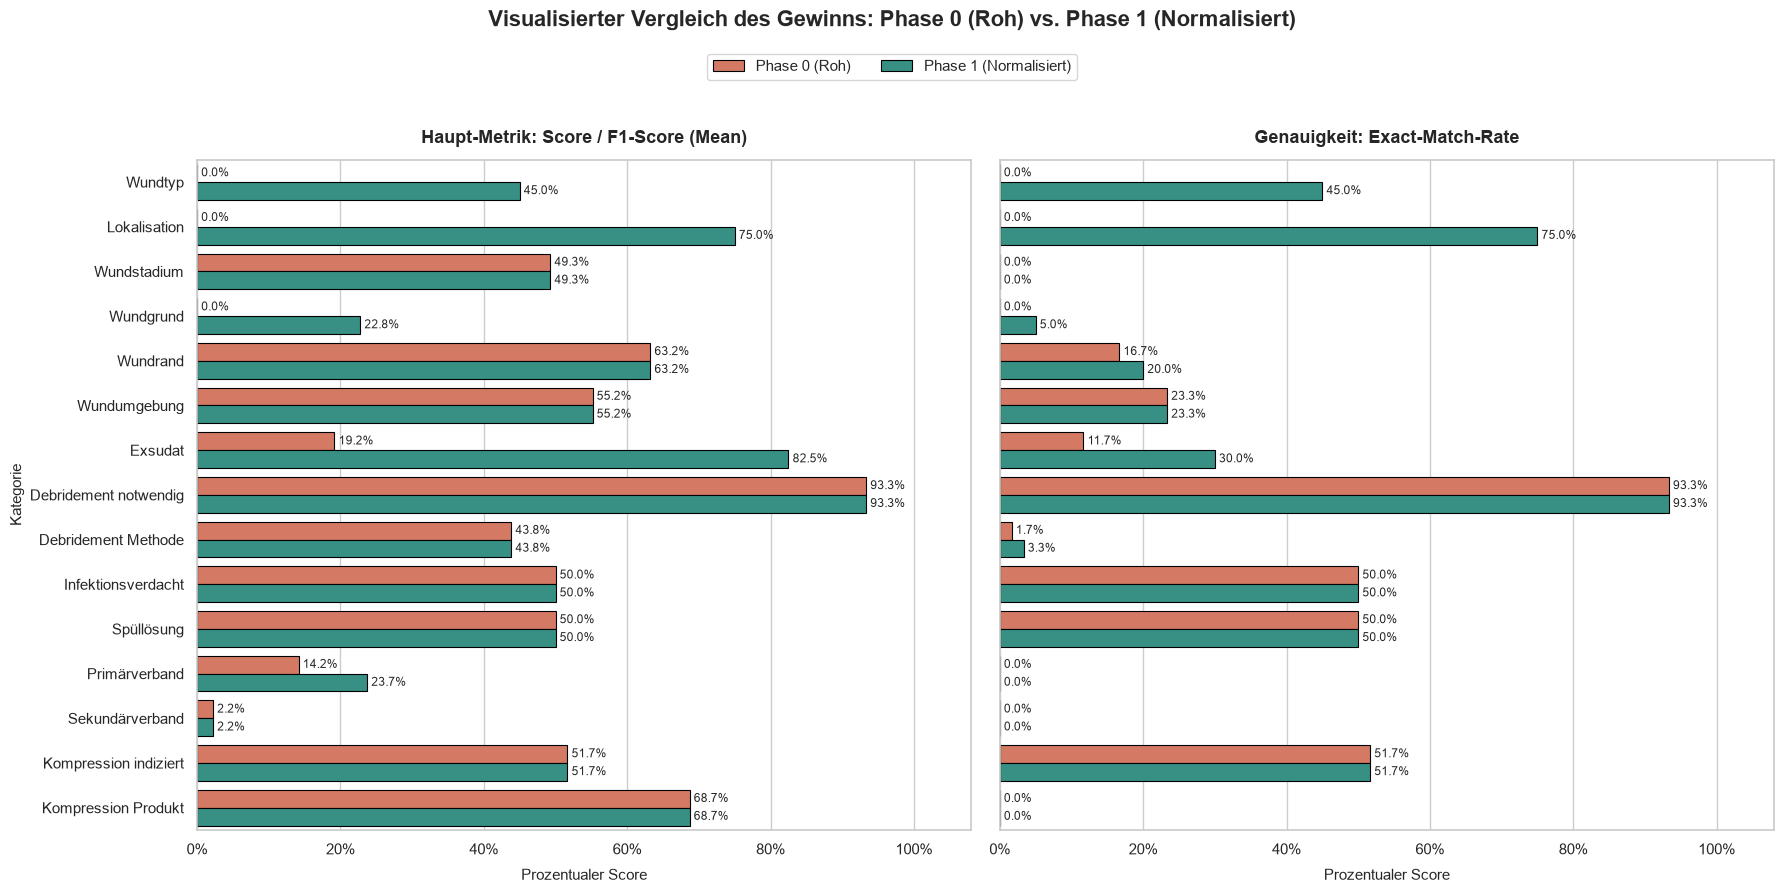

In [15]:
# =====================================================================
# GRAPHISCHER VERGLEICH (ROH vs. NORMALISIERT) FÜR BEIDE EXPERTEN
# =====================================================================

# --- EXPERTE 1 ---
df_summary_raw_exp1 = calculate_summary_LR(expert_id=1, normalised=False)
df_summary_norm_exp1 = calculate_summary_LR(expert_id=1, normalised=True)

plot_gt_comparison(df_summary_raw_exp1, df_summary_norm_exp1)

# --- EXPERTE 2 ---
df_summary_raw_exp2 = calculate_summary_LR(expert_id=2, normalised=False)
df_summary_norm_exp2 = calculate_summary_LR(expert_id=2, normalised=True)

plot_gt_comparison(df_summary_raw_exp2, df_summary_norm_exp2)

In [16]:
compare_wunden_trace_interactive()
compare_categories_trace_interactive()

Diagramm für die Übereinstimmung zwischen Experte 1 und 2 wird generiert...


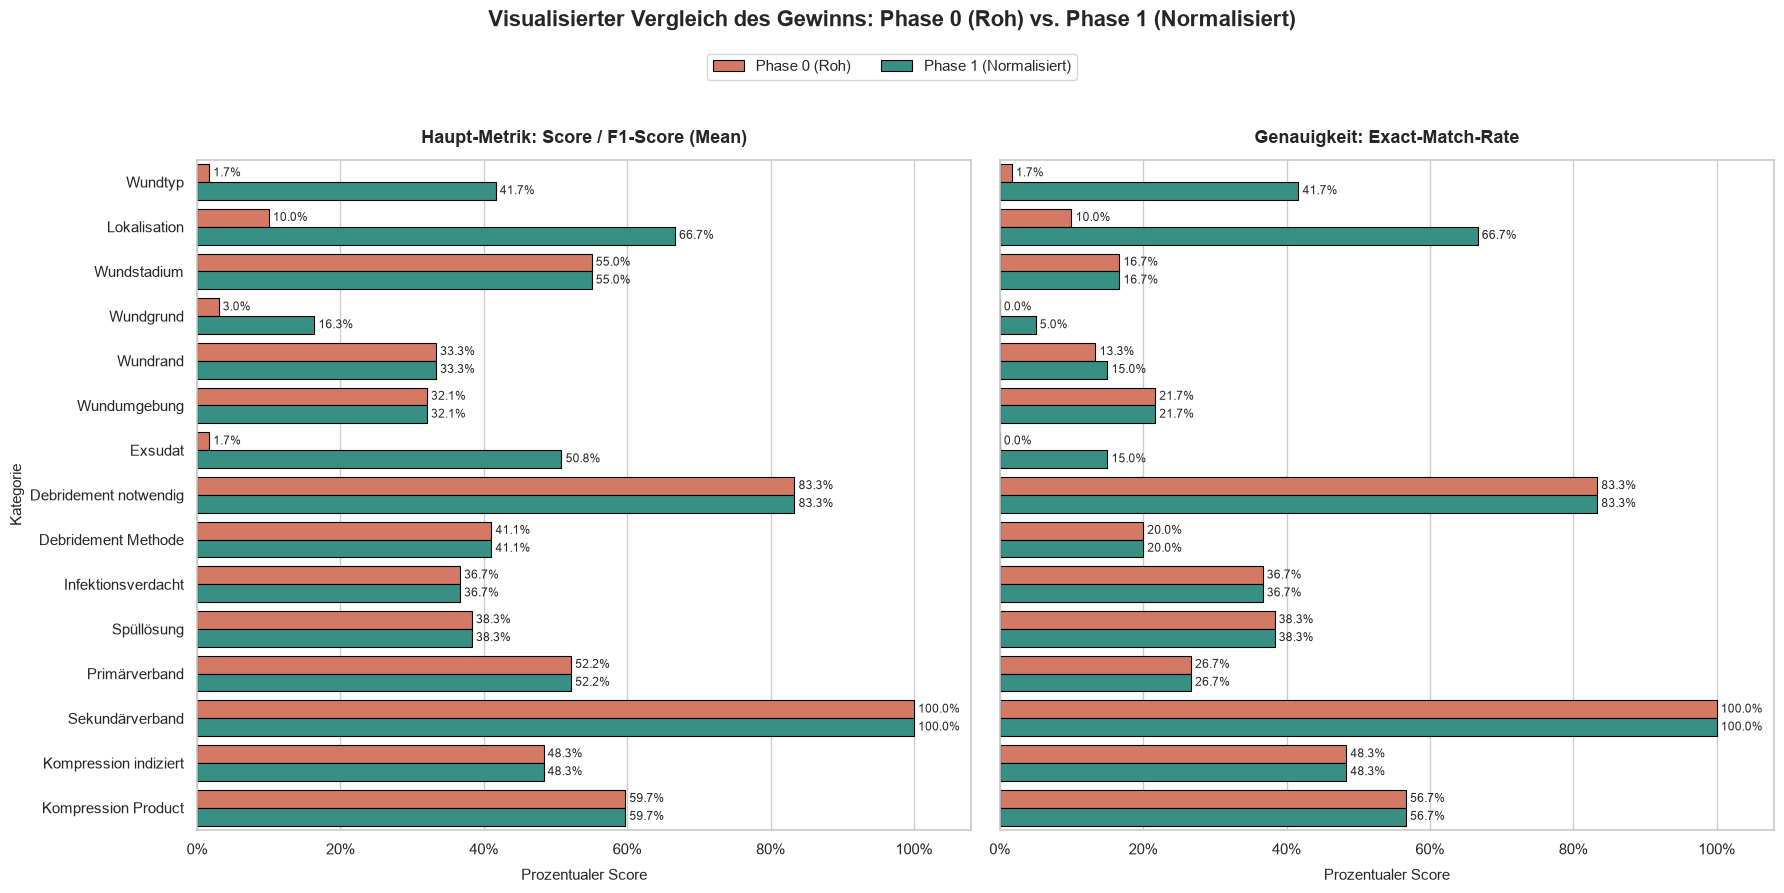

In [17]:
# =====================================================================
# ÜBEREINSTIMMUNG ZWISCHEN EXPERTE 1 UND EXPERTE 2 (ROH VS. NORMALISIERT)
# =====================================================================

# 1. Berechne die Übereinstimmung für beide Phasen (Roh vs. Normalisiert)
df_exp_raw = calculate_experts_summary_LR(normalised=False)
df_exp_norm = calculate_experts_summary_LR(normalised=True)

# 2. Zeichne das Vergleichsdiagramm
print("Diagramm für die Übereinstimmung zwischen Experte 1 und 2 wird generiert...")
plot_gt_comparison(df_exp_raw, df_exp_norm)

Diagramm für den Konsens-Score (Best-of-Both-Experts) wird generiert...


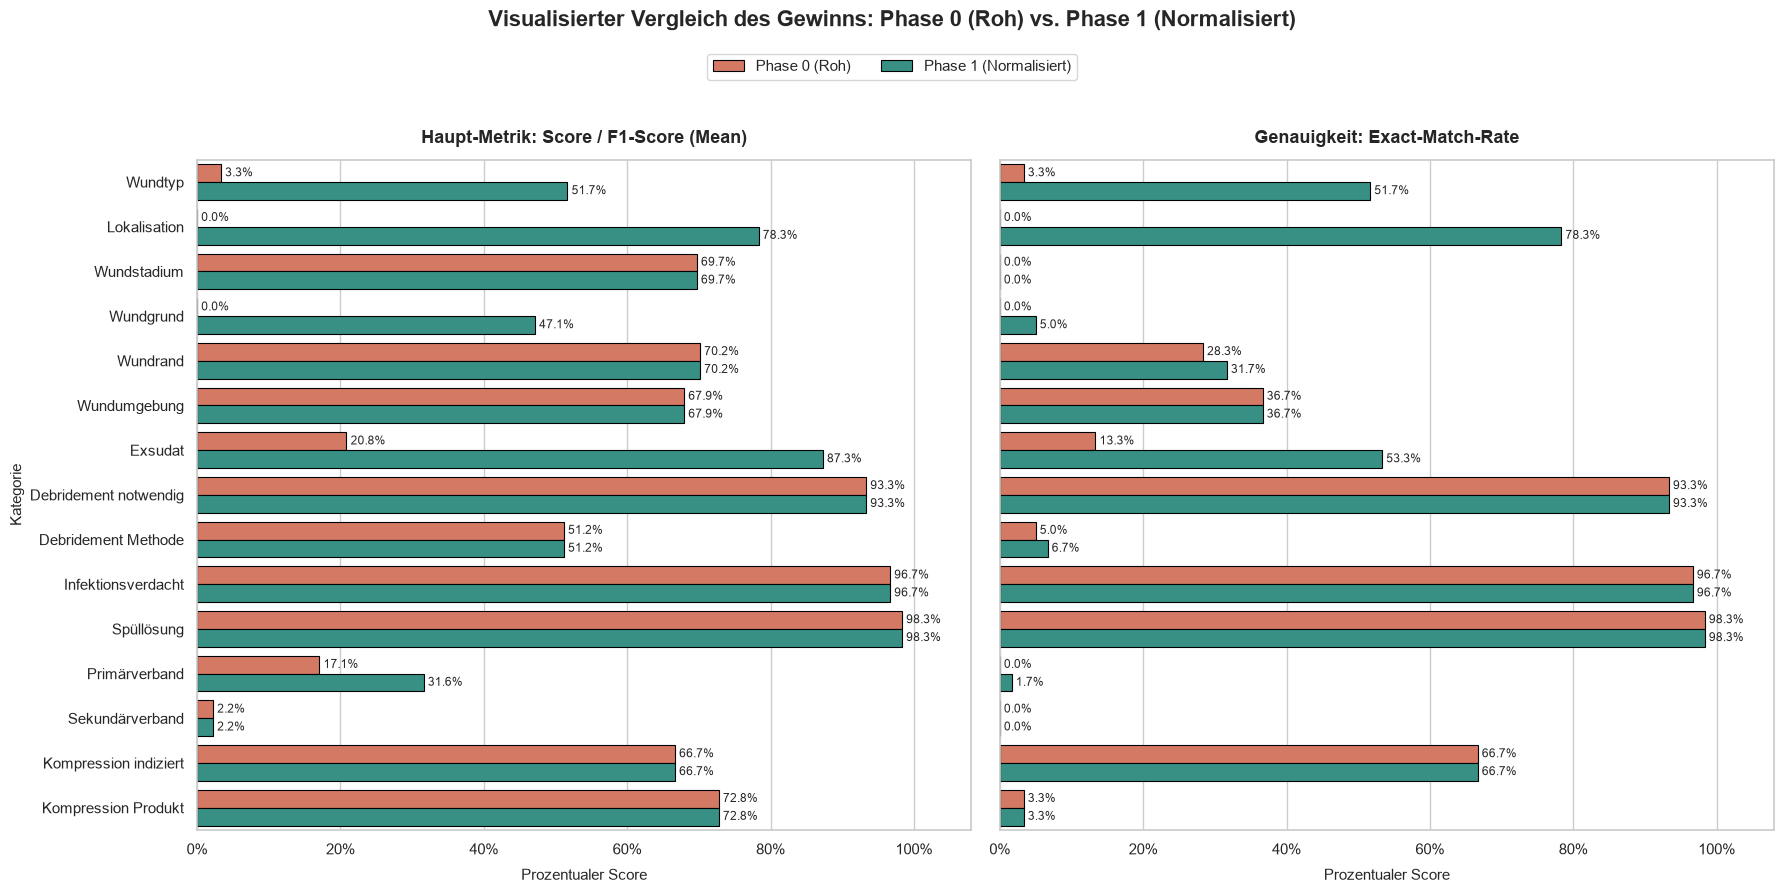

In [18]:
# =====================================================================
# KONSENS-SCORE (LLM VS. BEST-OF-BOTH-EXPERTS: MAXIMUM DER SCORES)
# =====================================================================

# 1. Berechne die Konsens-Zusammenfassungen für beide Phasen (Roh vs. Normalisiert)
df_consensus_raw = calculate_consensus_summary_LR(normalised=False)
df_consensus_norm = calculate_consensus_summary_LR(normalised=True)

# 2. Zeichne das Vergleichsdiagramm
print("Diagramm für den Konsens-Score (Best-of-Both-Experts) wird generiert...")
plot_gt_comparison(df_consensus_raw, df_consensus_norm)

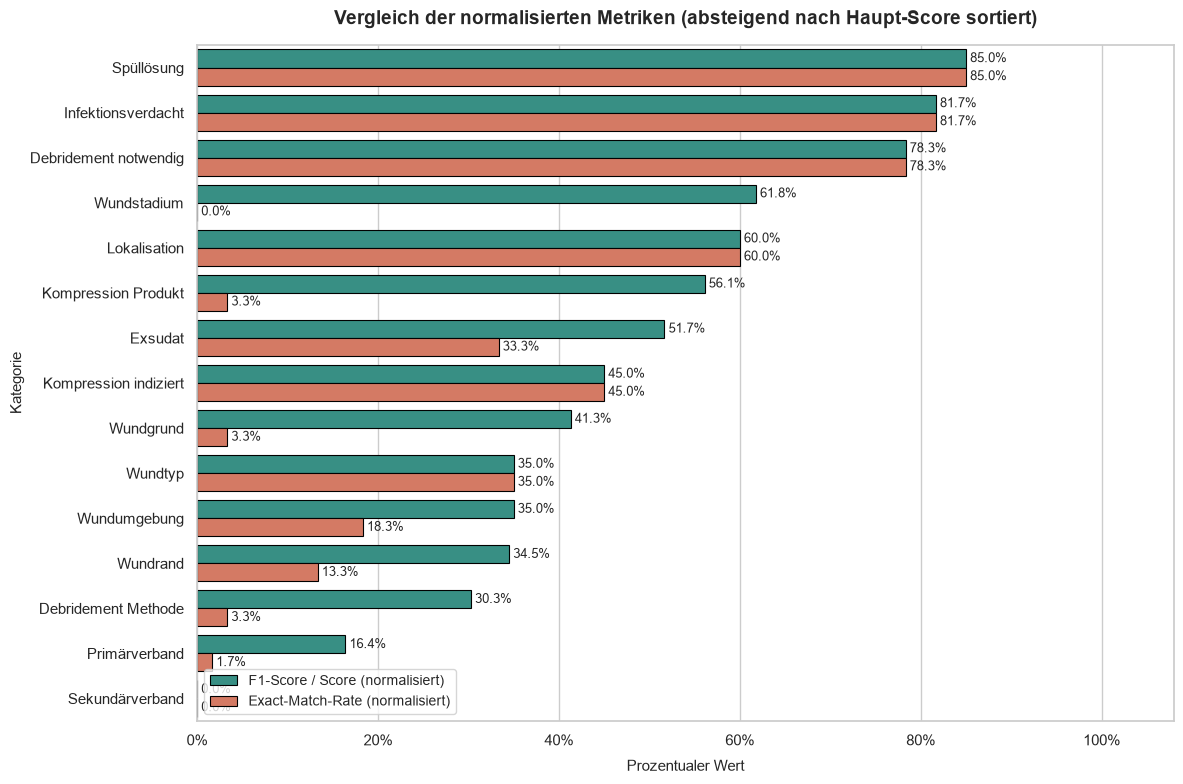

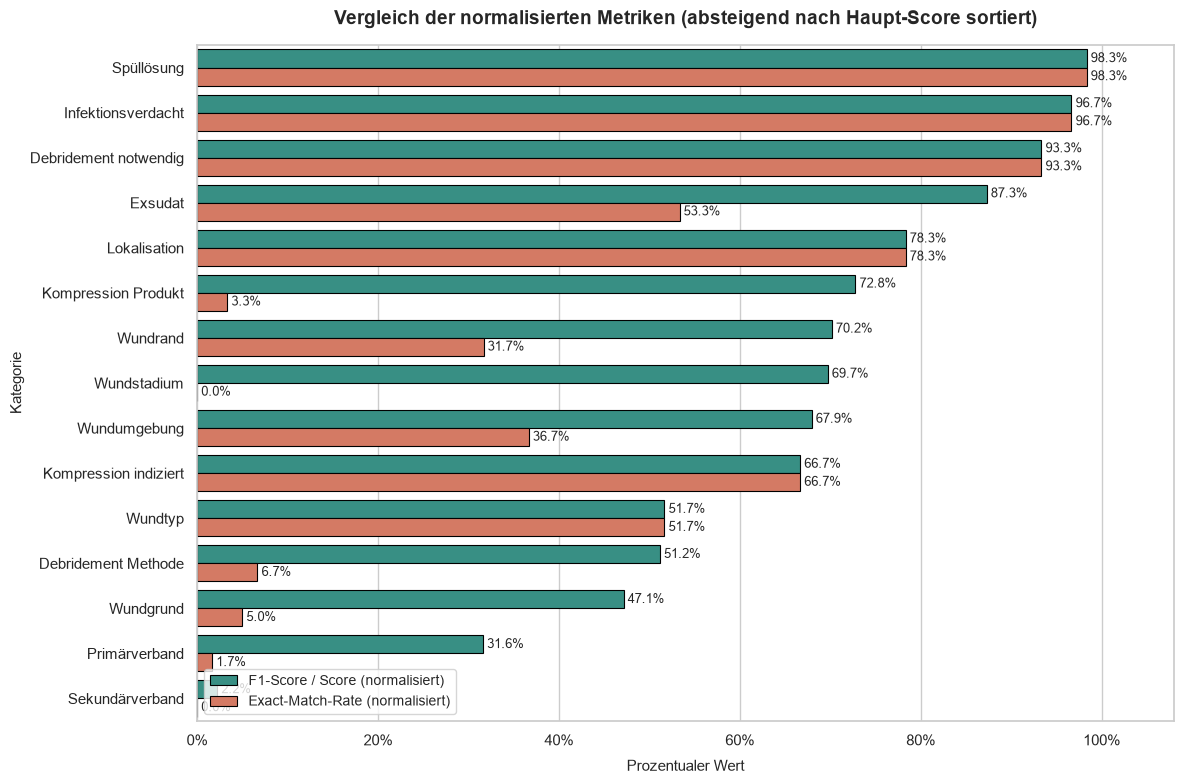

In [19]:
from utils_notebook.plot_compare import plot_sorted_norm_comparison

# Beispiel für Experte 1 (normalisiert)
plot_sorted_norm_comparison(df_summary_norm_exp1)

# Oder für den Konsensus (normalisiert)
plot_sorted_norm_comparison(df_consensus_norm)

In [20]:
from utils_notebook.LR_utils_notebook.product_sets_comparison import display_product_sets_comparison

# Führt die Berechnung aus und zeigt Zusammenfassung sowie Detailtabelle im L&R Design an:
df_summary, df_detail = display_product_sets_comparison()

Metrik / Vergleich,Score / F1-Score
Experten-Einigkeit untereinander (F1 Mean),33.3%
LLM vs. Experte 1 (F1 Mean),13.7%
LLM vs. Experte 2 (F1 Mean),20.7%
LLM Best Match (Max F1 Mean),23.9%
LLM Durchschnitt (Mean F1),17.2%


image_id,Experte 1 Produktset,Experte 2 Produktset,LLM Output Produktset,Experten-Einigkeit (F1),LLM vs Exp 1 (F1),LLM vs Exp 2 (F1),LLM Best Match (F1),LLM Mean (F1)
wunde_01,"debrisoft pad, suprasorb cnp","chirurgisches debridement, debrisoft lolly, suprasorb cnp, suprasorb x + phmb","autolytisches debridement, chirurgisches (scharfes) debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, vliwaktiv ag, vliwasorb pro",33.3%,0.0%,0.0%,0.0%,0.0%
wunde_02,"debrisoft pad, fixierbinden und universalbinden. rollenpflaster, solvaline n, suprasorb p + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb cnp, suprasorb x + phmb","curafix h, haftelast latexfrei, metalline kompresse, suprasorb p sensitive, suprasorb x, vliwazell",22.2%,0.0%,0.0%,0.0%,0.0%
wunde_03,suprasorb p sensiflex,"lomatuell pro, solvaline n, suprasorb p sensiflex","curafix h, lomatuell pro, silkafix, suprasorb liquacel pro, suprasorb p sensitive",50.0%,0.0%,25.0%,25.0%,12.5%
wunde_04,"debrisoft pad, solvaline n, suprasorb x + phmb, universalbinde und rollenpflaster","chirurgisches debridement, debrisoft lolly, suprasorb a + ag, suprasorb p + phmb, suprasorb p sensiflex","chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb p + phmb, suprasorb p sensitive",0.0%,0.0%,46.2%,46.2%,23.1%
wunde_05,"debrisoft duo, solvaline n, suprasorb x + phmb","chirurgisches debridement, lomatuell h, suprasorb x + phmb","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb a + ag, suprasorb liquacel pro, vliwasorb pro, vliwazell pro",33.3%,15.4%,15.4%,15.4%,15.4%
wunde_06,"fixierbinde und rollenpflaster, solvaline n, suprasorb x + phmb","chirurgisches debridement, debrisoft duo, solvaline n, suprasorb p + phmb","chirurgisches debridement, curafix h, debrisoft pad, lomatuell pro, porofix, silkafix, suprasorb p sensiflex, suprasorb p sensitive, suprasorb x pro",28.6%,0.0%,15.4%,15.4%,7.7%
wunde_07,"suprasorb cnp, ultraschall","debrisoft pad, lomatuell pro, suprasorb cnp, vliwazell pro","autolytisches debridement, curafix h, debrisoft duo, debrisoft pad, silkafix, suprasorb a pro, suprasorb liquacel pro, suprasorb p",33.3%,0.0%,16.7%,16.7%,8.3%
wunde_08,suprasorb p sensiflex,—,"autolytisches debridement, curafix h, curapor, curapor transparent, debrisoft pad, silkafix, suprasorb x, suprasorb x pro",0.0%,0.0%,0.0%,0.0%,0.0%
wunde_09,—,"chirurgisches debridement, debrisoft duo","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, silkafix, suprasorb f protect, suprasorb g gel-kompresse, suprasorb h",0.0%,0.0%,36.4%,36.4%,18.2%
wunde_10,"debrisoft duo, suprasorb f protect, suprasorb g gel-kompresse","chirurgisches debridement, debrisoft pad, solvaline n, suprasorb cnp, suprasorb liquacel pro, suprasorb x + phmb, vliwazell pro","autolytisches debridement, chirurgisches debridement, curafix h, debrisoft duo, porofix, suprasorb a pro, suprasorb liquacel pro, suprasorb p sensitive, vliwasorb pro",0.0%,16.7%,25.0%,25.0%,20.8%
